# Notebook 1: Data Ingestion, Cleaning, and Exploratory Data Analysis

## Purpose
This notebook is responsible for:
1. Loading the Open Food Facts dataset from Hugging Face
2. Sampling 500,000 products for our project
3. Extracting and flattening nested data structures
4. Filtering and cleaning the data
5. Performing exploratory data analysis
6. Saving the clean dataset as a Parquet file

## Output
- `project_data_clean.parquet`: Cleaned dataset ready for modeling
- EDA visualizations and insights

---

## 1. Setup and Imports

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
from tqdm import tqdm
import os
import json

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Load Raw Data from Hugging Face

We'll load the Open Food Facts dataset and take a random sample of 500,000 products.
A random sample is ideal for our project because we want maximum diversity to build a general-purpose search tool.

In [3]:
print("Loading Open Food Facts dataset from Hugging Face...")

# Load the dataset
ds = load_dataset("openfoodfacts/product-database", split="food")

print(f"\n Dataset loaded successfully!")
print(f"Total products in full dataset: {len(ds):,}")

Loading Open Food Facts dataset from Hugging Face...


Loading dataset shards:   0%|          | 0/54 [00:00<?, ?it/s]


 Dataset loaded successfully!
Total products in full dataset: 4,119,000


In [4]:
# Take a 500,000 product random sample
SAMPLE_SIZE = 500000

print(f"Shuffling and selecting {SAMPLE_SIZE:,} random products...")
ds_sample = ds.shuffle(seed=RANDOM_SEED).select(range(SAMPLE_SIZE))

# Convert to pandas DataFrame for easier manipulation
print("Converting to pandas DataFrame...")
df = ds_sample.to_pandas()

print(f"\n Sample created successfully!")
print(f"Sample size: {len(df):,} products")
print(f"Total columns: {len(df.columns)}")

Shuffling and selecting 500,000 random products...
Converting to pandas DataFrame...

 Sample created successfully!
Sample size: 500,000 products
Total columns: 110


In [5]:
# Explore the structure of the data
print("Sample of available columns:")
for i, col in enumerate(df.columns[:20]):
    print(f"{i+1:2}. {col}")
print(f"... and {len(df.columns) - 20} more columns\n")

# Check the structure of nested columns
print("\n Checking for nested structures:")
if 'nutriments' in df.columns:
    print("'nutriments' column found (contains nutritional data)")
    sample_nutriments = df['nutriments'].iloc[0]
    if isinstance(sample_nutriments, dict):
        print(f"  Sample keys: {list(sample_nutriments.keys())[:5]}...")

if 'images' in df.columns:
    print("'images' column found (contains image URLs)")
    sample_images = df['images'].iloc[0]
    if isinstance(sample_images, dict):
        print(f"  Sample structure: {type(sample_images)}")

Sample of available columns:
 1. additives_n
 2. additives_tags
 3. allergens_tags
 4. brands_tags
 5. brands
 6. categories
 7. categories_tags
 8. categories_properties
 9. checkers_tags
10. ciqual_food_name_tags
11. cities_tags
12. code
13. compared_to_category
14. complete
15. completeness
16. correctors_tags
17. countries_tags
18. created_t
19. creator
20. data_quality_errors_tags
... and 90 more columns


 Checking for nested structures:
'nutriments' column found (contains nutritional data)
'images' column found (contains image URLs)


## 3. Extract and Flatten Nested Data

The Open Food Facts dataset contains nested dictionaries for nutriments and images. We need to flatten these structures to access the data we need.

In [6]:
print("--- Starting Correct Data Extraction ---")

# --- 1. Get simple columns ---
print("Extracting simple columns...")
df_clean = df[['code', 'nutriscore_grade']].copy()

# --- 2. Process Complex Text (product_name, ingredients_text) ---
print("Extracting complex text (product_name, ingredients_text)...")
def extract_text(text_list_of_dicts, lang='en'):
    if not isinstance(text_list_of_dicts, list): return None
    if not text_list_of_dicts: return None
    for item in text_list_of_dicts:
        if isinstance(item, dict) and item.get('lang') == lang:
            return item.get('text')
    if isinstance(text_list_of_dicts[0], dict):
        return text_list_of_dicts[0].get('text')
    return None
df_clean['product_name'] = [extract_text(row) for row in ds_sample['product_name']]
df_clean['ingredients_text'] = [extract_text(row) for row in ds_sample['ingredients_text']]

# --- 3. Process Nutriments ---
print("Extracting nutriments...")
def find_nutrient_value(nutri_list, nutrient_name):
    if not isinstance(nutri_list, (list, np.ndarray)): return None
    for nutrient in nutri_list:
        if isinstance(nutrient, dict) and nutrient.get('name') == nutrient_name and '100g' in nutrient:
            return nutrient.get('100g')
    return None
nutriments_data = ds_sample['nutriments'] 
df_clean['kcal_100g'] = [find_nutrient_value(row, 'energy-kcal') for row in nutriments_data]
df_clean['proteins_100g'] = [find_nutrient_value(row, 'proteins') for row in nutriments_data]
df_clean['fat_100g'] = [find_nutrient_value(row, 'fat') for row in nutriments_data]
df_clean['carbs_100g'] = [find_nutrient_value(row, 'carbohydrates') for row in nutriments_data]

# --- 4. Process Tags ---
print("Extracting tags (categories, allergens)...")
def process_tags(tags_list, default=None):
    if not isinstance(tags_list, (list, np.ndarray)): return default
    if not tags_list: return default
    clean_tags = [str(tag).replace('en:', '').replace('-', ' ') for tag in tags_list if isinstance(tag, str)]
    return ', '.join(clean_tags) if clean_tags else default
df_clean['categories_en'] = [process_tags(row, default=None) for row in ds_sample['categories_tags']]
df_clean['allergens_en'] = [process_tags(row, default='none') for row in ds_sample['allergens_tags']]


# --- 5. IMAGES (FINAL FIX) ---
# We now *construct* the URL based on the documentation, we don't *extract* it.
print("Constructing image URLs...")

def construct_image_url(code, images_data):
    # This function uses the product 'code' (barcode) to build the URL.
    # It also checks the 'images' metadata to see if a front image (key '1') actually exists.
    
    if not isinstance(code, str) or len(code) < 9:
        return None # Code is invalid, can't build URL
        
    # Check if a front image (key '1') is listed in the metadata
    has_front_image = False
    if isinstance(images_data, (list, np.ndarray)):
        for img in images_data:
            if isinstance(img, dict) and img.get('key') == '1':
                has_front_image = True
                break
    
    if not has_front_image:
        return None # No front image is registered for this product

    # --- Build the URL Path (e.g., "343/566/076/8163") ---
    # Pad with 0s if code is less than 13 digits
    code_padded = code.zfill(13)
    
    # Split into groups: 3 / 3 / 3 / 4
    if len(code_padded) >= 13:
         path = f"{code_padded[0:3]}/{code_padded[3:6]}/{code_padded[6:9]}/{code_padded[9:13]}"
    elif len(code_padded) >= 9:
        path = f"{code_padded[0:3]}/{code_padded[3:6]}/{code_padded[6:9]}/{code_padded[9:]}"
    elif len(code_padded) >= 6:
        path = f"{code_padded[0:3]}/{code_padded[3:6]}/{code_padded[6:]}"
    elif len(code_padded) >= 3:
        path = f"{code_padded[0:3]}/{code_padded[3:]}"
    else:
        path = code_padded

    # --- Construct Final URL ---
    # We will use the 400px version ('1.400.jpg')
    base_url = "https://images.openfoodfacts.org/images/products"
    return f"{base_url}/{path}/1.400.jpg"

# We must iterate over the rows using 'zip' to get both 'code' and 'images'
image_urls = []
for code, images_data in zip(ds_sample['code'], ds_sample['images']):
    image_urls.append(construct_image_url(code, images_data))
    
df_clean['image_url'] = image_urls

print("\n Data extraction and flattening complete.")

# --- This is your NEW 'df_filtered' ---
df_filtered = df_clean 

# Now, let's check the non-null counts again
print("\n--- New Column Status ---")
final_columns = [
    'code', 'product_name', 'categories_en', 'ingredients_text', 
    'image_url', 'allergens_en', 'nutriscore_grade', 'kcal_100g', 
    'proteins_100g', 'fat_100g', 'carbs_100g'
]
available_cols = [col for col in final_columns if col in df_filtered.columns]

for col in available_cols:
    non_null = df_filtered[col].notna().sum()
    print(f"  - {col}: {non_null:,} non-null values ({non_null/len(df_filtered)*100:.1f}%)")

--- Starting Correct Data Extraction ---
Extracting simple columns...
Extracting complex text (product_name, ingredients_text)...
Extracting nutriments...
Extracting tags (categories, allergens)...
Constructing image URLs...

 Data extraction and flattening complete.

--- New Column Status ---
  - code: 500,000 non-null values (100.0%)
  - product_name: 467,223 non-null values (93.4%)
  - categories_en: 211,868 non-null values (42.4%)
  - ingredients_text: 143,703 non-null values (28.7%)
  - image_url: 366,085 non-null values (73.2%)
  - allergens_en: 500,000 non-null values (100.0%)
  - nutriscore_grade: 494,608 non-null values (98.9%)
  - kcal_100g: 358,648 non-null values (71.7%)
  - proteins_100g: 361,202 non-null values (72.2%)
  - fat_100g: 360,686 non-null values (72.1%)
  - carbs_100g: 361,025 non-null values (72.2%)


## 4. Data Cleaning

This is our "smart filter" - we'll remove products that lack critical information needed for our models.

In [7]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print("-" * 50)
missing_stats = pd.DataFrame({
    'Column': df_filtered.columns,
    'Missing_Count': df_filtered.isnull().sum(),
    'Missing_Percentage': (df_filtered.isnull().sum() / len(df_filtered) * 100).round(2)
})
print(missing_stats.to_string(index=False))
print(f"\nTotal products before cleaning: {len(df_filtered):,}")

Missing values before cleaning:
--------------------------------------------------
          Column  Missing_Count  Missing_Percentage
            code              0                0.00
nutriscore_grade           5392                1.08
    product_name          32777                6.56
ingredients_text         356297               71.26
       kcal_100g         141352               28.27
   proteins_100g         138798               27.76
        fat_100g         139314               27.86
      carbs_100g         138975               27.80
   categories_en         288132               57.63
    allergens_en              0                0.00
       image_url         133915               26.78

Total products before cleaning: 500,000


In [8]:
# Drop products missing critical information
# These are essential for our multi-modal search system
critical_columns = [
    'product_name',           # Need product name for display
    'ingredients_text',       # Need ingredients for text search
    'image_url',             # Need image URL for visual search
    'proteins_100g'          # Need at least one nutritional value
]

print(f"Removing products missing critical information...")
df_clean = df_filtered.dropna(subset=critical_columns).copy()

print(f"Products removed: {len(df_filtered) - len(df_clean):,}")
print(f"Products remaining: {len(df_clean):,}")
print(f"Retention rate: {(len(df_clean) / len(df_filtered) * 100):.1f}%")

Removing products missing critical information...
Products removed: 417,805
Products remaining: 82,195
Retention rate: 16.4%


In [15]:
# Additional data cleaning
# Fill missing allergens
if 'allergens_en' not in df_clean.columns:
    df_clean['allergens_en'] = 'none'
else:
    df_clean['allergens_en'] = df_clean['allergens_en'].fillna('none')

# Convert code to string to ensure consistency
df_clean['code'] = df_clean['code'].astype(str)

# Clean numeric columns - convert to float and handle invalid values
numeric_columns = ['kcal_100g', 'proteins_100g', 'fat_100g', 'carbs_100g']
for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Remove products with unrealistic nutritional values
print("\nRemoving products with unrealistic nutritional values...")
initial_count = len(df_clean)

# Rule 1: Calories <= 900 (pure fat is ~900 kcal)
if 'kcal_100g' in df_clean.columns:
    df_clean = df_clean[df_clean['kcal_100g'] <= 900]

# Rule 2: All macronutrients must be between 0 and 100
if 'proteins_100g' in df_clean.columns:
    df_clean = df_clean[df_clean['proteins_100g'].between(0, 100)]

if 'fat_100g' in df_clean.columns:
    df_clean = df_clean[df_clean['fat_100g'].between(0, 100)]
    
if 'carbs_100g' in df_clean.columns:
    df_clean = df_clean[df_clean['carbs_100g'].between(0, 100)]

df_clean = df_clean.dropna(subset=numeric_columns)

print(f"Products removed due to unrealistic values or new NaNs: {initial_count - len(df_clean):,}")
print(f"Final cleaned products: {len(df_clean):,}")

print("\n Data cleaning complete!")


Removing products with unrealistic nutritional values...
Products removed due to unrealistic values or new NaNs: 4,987
Final cleaned products: 76,935

 Data cleaning complete!


In [16]:
# Display sample of cleaned data
print("Sample of cleaned data:")
df_clean.head()

Sample of cleaned data:


,code,nutriscore_grade,product_name,ingredients_text,kcal_100g,proteins_100g,fat_100g,carbs_100g,categories_en,allergens_en,image_url
3,4056489135968,b,Potato Waffles,"85% Potato, 8% Sunflower Oil, Potato Starch, D...",203.000000,2.41,9.48,25.700001,"snacks, sweet snacks, biscuits and cakes, past...",none,https://images.openfoodfacts.org/images/produc...
14,4311501048030,unknown,Vollmilch,Vollmilch,66.000000,3.50,3.60,4.800000,None,milk,https://images.openfoodfacts.org/images/produc...
15,0845681001577,unknown,Dairy Free Butter,"wayfare dairy free base (water, butter beans),...",428.571442,0.00,50.00,0.000000,None,none,https://images.openfoodfacts.org/images/produc...
42,3250392934392,e,Tablette fourrée chocolat au lait caramel à la...,"Sucre, caramel au lait frais d'Isigny et à la ...",489.000000,6.40,25.00,60.000000,fr:chocolat au lait basique fourre,milk,https://images.openfoodfacts.org/images/produc...
56,4335619058750,e,Muesli Bar Banana,"sugar, glucose syrup, cocoa butter, whole milk...",425.000000,5.00,16.00,62.000000,"snacks, sweet snacks, bars, cereal bars",milk,https://images.openfoodfacts.org/images/produc...


## 5. Exploratory Data Analysis (EDA)

Let's explore our cleaned dataset to understand the distribution of products and their nutritional values.

In [17]:
# Summary statistics for numerical columns
print("Summary Statistics for Nutritional Values:")
nutritional_cols = ['kcal_100g', 'proteins_100g', 'fat_100g', 'carbs_100g']
available_nutritional = [col for col in nutritional_cols if col in df_clean.columns]

if available_nutritional:
    print(df_clean[available_nutritional].describe())

Summary Statistics for Nutritional Values:
          kcal_100g  proteins_100g      fat_100g    carbs_100g
count  76935.000000   76935.000000  76935.000000  76935.000000
mean     270.547750       8.187910     13.266080     29.061410
std      188.667072       9.732417     17.160144     27.669399
min        0.000000       0.000000      0.000000      0.000000
25%      100.000000       1.500000      0.806000      4.600000
50%      258.000000       5.800000      6.500000     17.000000
75%      400.000000      11.000000     20.799999     54.000000
max      900.000000     100.000000    100.000000    100.000000


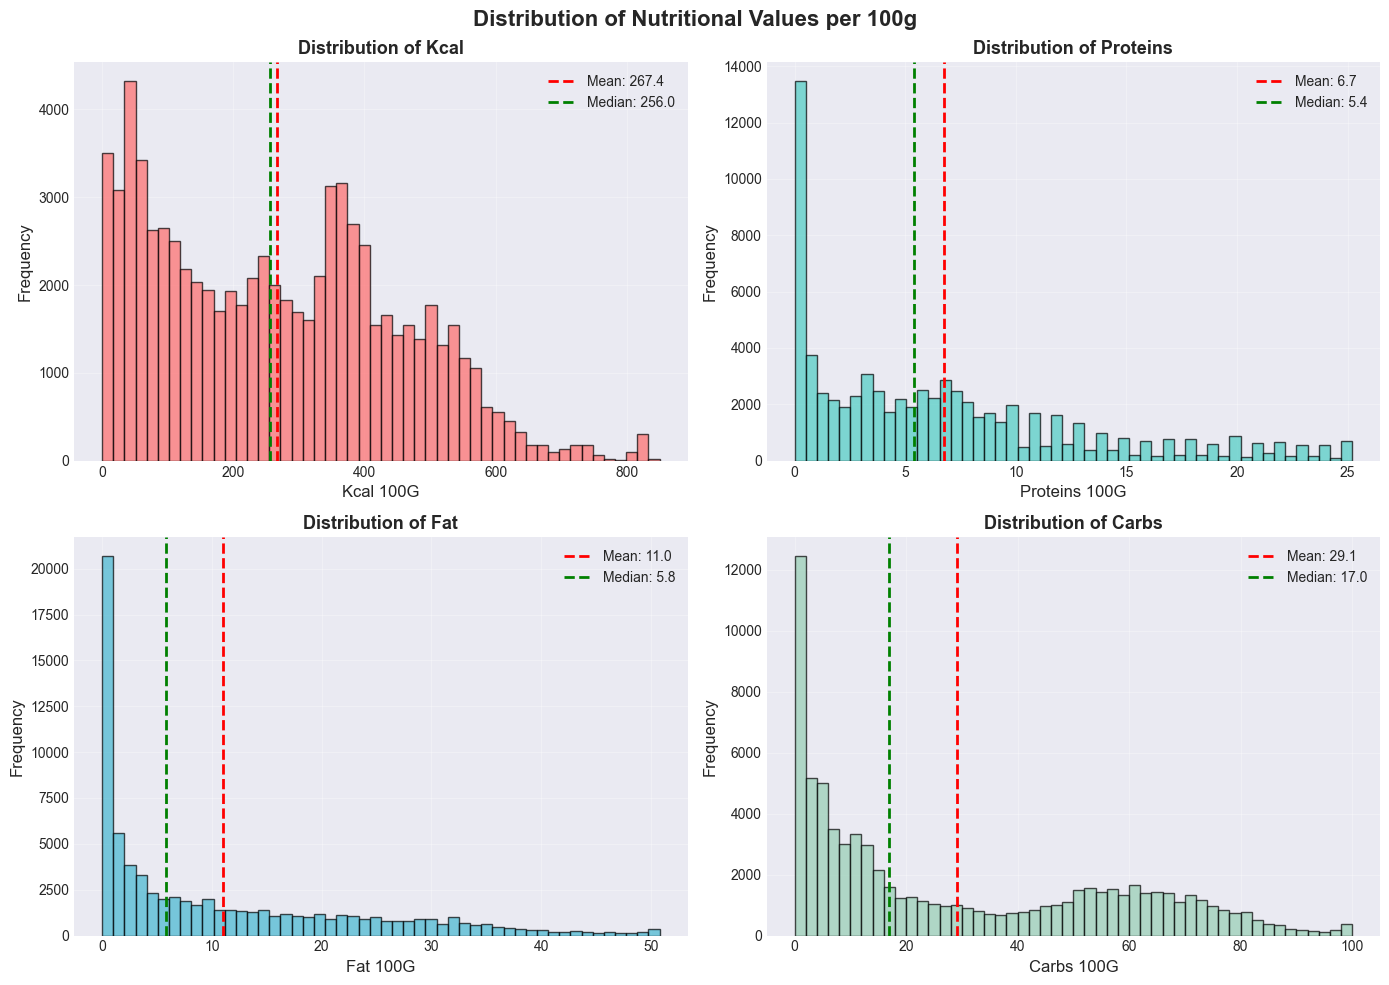

Note: Outliers removed using IQR method for better visualization


In [18]:
# Create visualizations for nutritional distributions
available_nutritional = [col for col in nutritional_cols if col in df_clean.columns]

if available_nutritional:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle('Distribution of Nutritional Values per 100g', fontsize=16, fontweight='bold')
    
    # Define colors for each nutrient
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for idx, (col, ax, color) in enumerate(zip(available_nutritional, axes, colors)):
        # Remove outliers for better visualization (using IQR method)
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        filtered_data = df_clean[col][
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ].dropna()
        
        # Create histogram
        ax.hist(filtered_data, bins=50, color=color, alpha=0.7, edgecolor='black')
        ax.axvline(filtered_data.mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {filtered_data.mean():.1f}')
        ax.axvline(filtered_data.median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {filtered_data.median():.1f}')
        
        ax.set_xlabel(col.replace('_', ' ').title(), fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'Distribution of {col.replace("_100g", "").title()}', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots if less than 4 nutritional columns
    for idx in range(len(available_nutritional), 4):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("Note: Outliers removed using IQR method for better visualization")
else:
    print("No nutritional columns available for visualization")

### 1. Summary: Nutritional Distributions

- **Right-Skewed Data:** All four nutrients show a strong right-skew, which is expected for this kind of data. The **Mean** (red line) is consistently pulled higher than the **Median** (green line) by a long tail of high-value products (e.g., a small number of very high-fat or high-protein items).

- **Bimodal Calories:** The `kcal_100g` plot appears bimodal, with one peak around 100–150 kcal (likely drinks, fruits, and light snacks) and another, broader peak around 400 kcal (denser foods like cheeses, meats, and processed snacks).

- **Insight:** This skew confirms that filtering by simple averages would be misleading. Our system will be more effective if it filters using specific user-defined ranges (e.g., “protein > 20g”) or median-based logic.


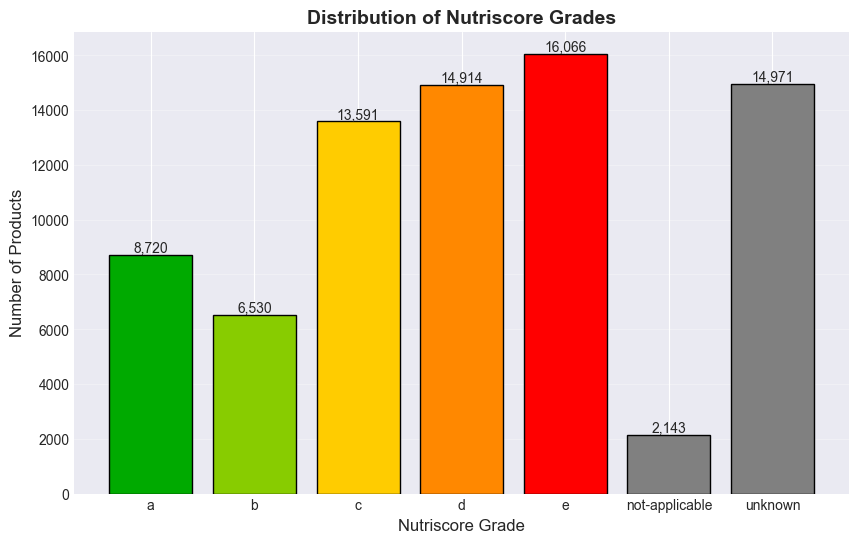

Nutriscore Grade Distribution:
nutriscore_grade
a                  8720
b                  6530
c                 13591
d                 14914
e                 16066
not-applicable     2143
unknown           14971


In [19]:
# Analyze Nutriscore distribution
if 'nutriscore_grade' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    
    nutriscore_counts = df_clean['nutriscore_grade'].value_counts().sort_index()
    colors_nutri = {'a': '#00AA00', 'b': '#88CC00', 'c': '#FFCC00', 'd': '#FF8800', 'e': '#FF0000'}
    bar_colors = [colors_nutri.get(x.lower(), '#808080') if pd.notna(x) else '#808080' 
                  for x in nutriscore_counts.index]
    
    bars = plt.bar(nutriscore_counts.index.astype(str), nutriscore_counts.values, 
                   color=bar_colors, edgecolor='black')
    
    plt.title('Distribution of Nutriscore Grades', fontsize=14, fontweight='bold')
    plt.xlabel('Nutriscore Grade', fontsize=12)
    plt.ylabel('Number of Products', fontsize=12)
    
    # Add value labels on bars
    for bar, value in zip(bars, nutriscore_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                f'{value:,}', ha='center', fontsize=10)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()
    
    print("Nutriscore Grade Distribution:")
    print(nutriscore_counts.to_string())
else:
    print("Nutriscore data not available")

### 2. Summary: Nutriscore Grades

- **Distribution:** The data is heavily skewed towards less healthy products. The grades **c, d, and e** are significantly more common than the healthier **a and b** grades, with **e** being the single most frequent category.

- **Missing Data:** A very large portion of the dataset is `unknown` (14,971) or `not-applicable` (2,143). When building filters, we must treat `unknown` as a separate category, not as “healthy” or “unhealthy.”

- **Insight:** This provides a clear value proposition for our tool. A user will get significant benefit from a search that can specifically filter for the relatively rare **a and b** grade products.


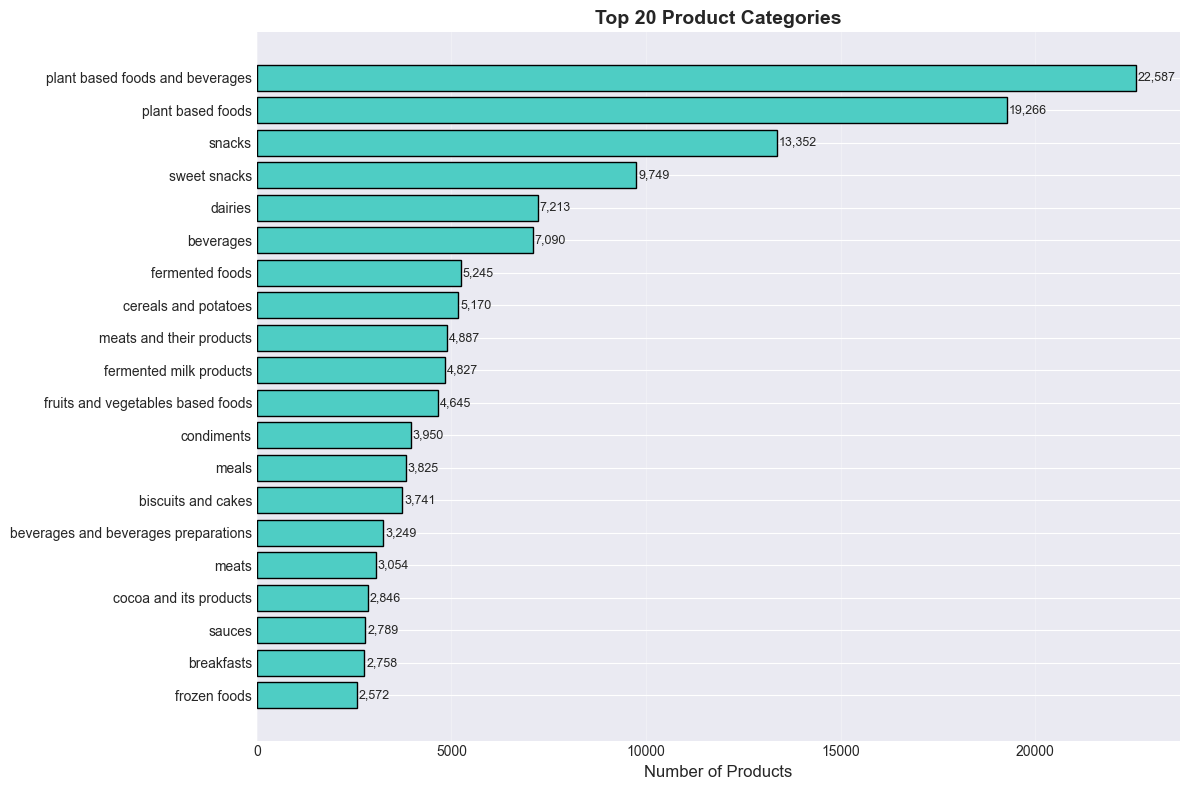

Total unique categories found: 3,522
Products with category information: 66,632


In [20]:
# Analyze top product categories
if 'categories_en' in df_clean.columns:
    # Extract and count categories
    all_categories = []
    
    for cats in df_clean['categories_en'].dropna():
        if isinstance(cats, str):
            # Split by comma and clean each category
            categories = [cat.strip() for cat in cats.split(',')]
            all_categories.extend(categories[:3])  # Take first 3 categories to avoid too much detail
    
    # Count categories
    from collections import Counter
    category_counts = Counter(all_categories)
    top_20_categories = dict(category_counts.most_common(20))
    
    # Create bar plot
    plt.figure(figsize=(12, 8))
    categories = list(top_20_categories.keys())
    counts = list(top_20_categories.values())
    
    bars = plt.barh(range(len(categories)), counts, color='#4ECDC4', edgecolor='black')
    plt.yticks(range(len(categories)), categories)
    
    plt.xlabel('Number of Products', fontsize=12)
    plt.title('Top 20 Product Categories', fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar, value in zip(bars, counts):
        plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
                f'{value:,}', va='center', fontsize=9)
    
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print(f"Total unique categories found: {len(category_counts):,}")
    print(f"Products with category information: {df_clean['categories_en'].notna().sum():,}")
else:
    print("Categories data not available")

### 3. Summary: Top 20 Product Categories

- **Data Redundancy:** The top two categories, **“plant based foods and beverages”** and **“plant based foods”**, are nearly identical. This indicates that the category data is “noisy” and contains parent–child relationships (e.g., `snacks`, `sweet snacks`).

- **High Diversity:** We have a very diverse dataset, with **3,522 unique categories** found in our 76k dataset. This is excellent for a general-purpose search engine.

- **Insight:** We cannot build a simple classifier for all 3,522 categories. However, the Top 20 are very strong and provide clear, popular labels (like “snacks,” “dairies,” “beverages”) that we can use for filtering or as training targets for our baseline image classifier.


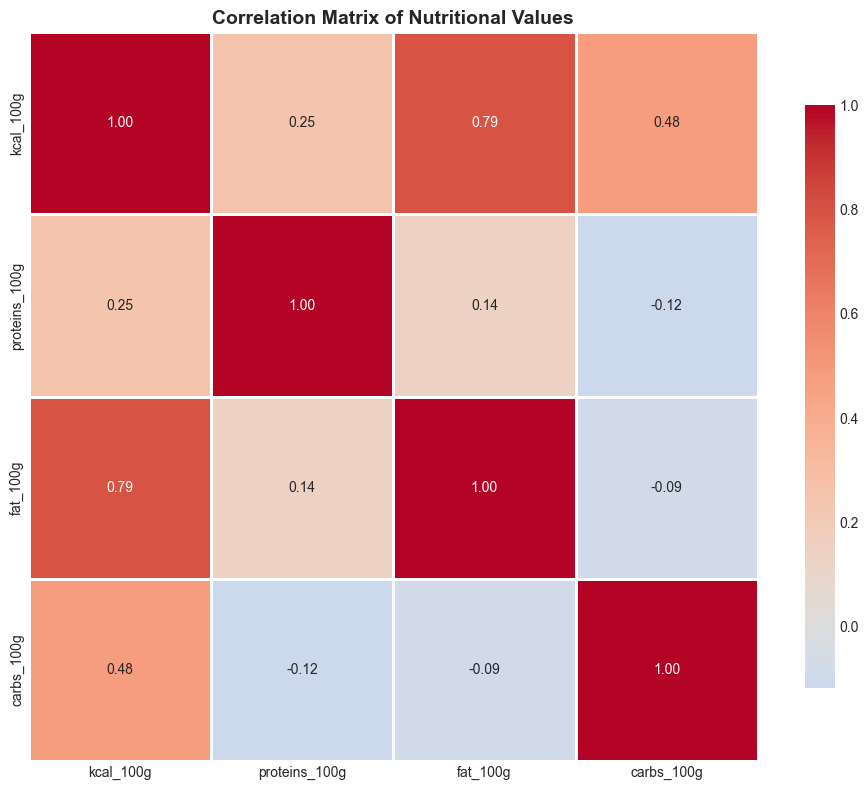

Key Insights:
- Strong correlations indicate nutritional patterns
- This will help in building better search filters


In [21]:
# Correlation analysis of nutritional values
if available_nutritional:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df_clean[available_nutritional].corr()
    
    # Create heatmap
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    
    plt.title('Correlation Matrix of Nutritional Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key Insights:")
    print("- Strong correlations indicate nutritional patterns")
    print("- This will help in building better search filters")
else:
    print("Not enough nutritional data for correlation analysis")

### 4. Summary: Correlation Matrix

- **Strongest Correlation:** The matrix confirms real-world nutritional science. The strongest positive correlation is between `kcal_100g` and `fat_100g` (**0.79**), as fat is the most calorie-dense nutrient (9 kcal/g).

- **Other Correlations:** `kcal_100g` also has a moderate positive correlation with `carbs_100g` (**0.48**) and a weaker one with `proteins_100g` (**0.25**).

- **Inverse Relationship:** We see a slight negative correlation between `proteins_100g` and `carbs_100g` (**-0.12**). This reflects common food patterns: products tend to be either high-protein (like meat, cheese) or high-carb (like bread, pasta), but rarely both.

- **Insight:** This confirms that our cleaned data is logical and reflects real nutritional patterns. The model will be able to learn these relationships.


## 6. Data Quality Report

In [23]:
# Generate comprehensive data quality report
print("DATA QUALITY REPORT".center(60))

print(f"\n Dataset Overview:")
print(f"  • Total products: {len(df_clean):,}")
print(f"  • Total features: {len(df_clean.columns)}")

print(f"\n Data Completeness:")
for col in df_clean.columns:
    completeness = (df_clean[col].notna().sum() / len(df_clean)) * 100
    print(f"  • {col}: {completeness:.1f}% complete")

print(f"\n Nutritional Statistics:")
for col in available_nutritional:
    if col in df_clean.columns:
        non_null = df_clean[col].dropna()
        if len(non_null) > 0:
            print(f"  • {col}:")
            print(f"    - Mean: {non_null.mean():.2f}")
            print(f"    - Median: {non_null.median():.2f}")
            print(f"    - Std Dev: {non_null.std():.2f}")

print(f"\n Key Insights:")
if available_nutritional:
    print(f"  • Products with all nutritional values: {df_clean[available_nutritional].notna().all(axis=1).sum():,}")
if 'nutriscore_grade' in df_clean.columns:
    print(f"  • Products with Nutriscore: {df_clean['nutriscore_grade'].notna().sum():,}")
print(f"  • Products with allergen info: {(df_clean['allergens_en'] != 'none').sum():,}")
print(f"  • Products with images: {df_clean['image_url'].notna().sum():,}")

                    DATA QUALITY REPORT                     

 Dataset Overview:
  • Total products: 76,935
  • Total features: 11

 Data Completeness:
  • code: 100.0% complete
  • nutriscore_grade: 100.0% complete
  • product_name: 100.0% complete
  • ingredients_text: 100.0% complete
  • kcal_100g: 100.0% complete
  • proteins_100g: 100.0% complete
  • fat_100g: 100.0% complete
  • carbs_100g: 100.0% complete
  • categories_en: 86.6% complete
  • allergens_en: 100.0% complete
  • image_url: 100.0% complete

 Nutritional Statistics:
  • kcal_100g:
    - Mean: 270.55
    - Median: 258.00
    - Std Dev: 188.67
  • proteins_100g:
    - Mean: 8.19
    - Median: 5.80
    - Std Dev: 9.73
  • fat_100g:
    - Mean: 13.27
    - Median: 6.50
    - Std Dev: 17.16
  • carbs_100g:
    - Mean: 29.06
    - Median: 17.00
    - Std Dev: 27.67

 Key Insights:
  • Products with all nutritional values: 76,935
  • Products with Nutriscore: 76,935
  • Products with allergen info: 47,301
  • Products with 

## 7. Save Cleaned Dataset

In [24]:
# Save the cleaned dataset
output_file = 'project_data_clean.parquet'

print(f"Saving cleaned dataset to {output_file}...")
df_clean.to_parquet(output_file, index=False, compression='snappy')

# Verify the saved file
file_size = os.path.getsize(output_file) / (1024**2)  # Size in MB
print(f"\n Dataset saved successfully!")
print(f"  • Filename: {output_file}")
print(f"  • File size: {file_size:.2f} MB")
print(f"  • Products: {len(df_clean):,}")
print(f"  • Columns: {len(df_clean.columns)}")

# Quick verification - load and check
df_verify = pd.read_parquet(output_file)
assert len(df_verify) == len(df_clean), "Verification failed: row count mismatch"
assert list(df_verify.columns) == list(df_clean.columns), "Verification failed: column mismatch"
print(f"\n Verification passed! File is ready for use.")

Saving cleaned dataset to project_data_clean.parquet...

 Dataset saved successfully!
  • Filename: project_data_clean.parquet
  • File size: 19.46 MB
  • Products: 76,935
  • Columns: 11

 Verification passed! File is ready for use.


## 8. Next Steps

### Completed in this notebook:
1. Loaded 500,000 random products from Open Food Facts
2. Extracted and flattened nested data structures (nutriments, images)
3. Processed categories and allergens from tags
4. Filtered to relevant columns for multi-modal search
5. Cleaned data by removing incomplete records
6. Performed comprehensive EDA
7. Saved clean dataset as `project_data_clean.parquet`

### TODO for Data Team:
1. **Run the image download script** (`download_images.py`) to fetch product images
2. **Upload to shared drive**:
   - `project_data_clean.parquet`
   - `images.zip` (after downloading images)
3. **Share the DATA_DRIVE_URL** with the team

### Next notebooks:
- **Notebook 2**: Baseline Models (TF-IDF and Simple CNN)
- **Notebook 3**: Advanced Embeddings (BERT and ViT)
- **Notebook 4**: RAG Pipeline Implementation